# Mileston 2: Employee Attrition Machine Learning Model

## Introduction

Name: Bramantyo Anandaru Suyadi

Batch: HCK-023

Objective:
This model is created to predict if an employee will be attrited from the company or not. The Machine Learning algorithm is a classification one and will use recall as the main metric and ROC AUC as secondary metric to check if it is a good fit.

## Problem Identification

### Background
Attrition is when an employee leaves a company caused by resignation, being fired, death, and other types of reason that can cause him/her to be removed from the company. Attrition is different from turnover because turnover is when an employee leaves the company voluntarily (Hayes, 2022). Companies use attrition rate to measure the number of employees leaving the organization. This rate will be seen by potential candidates who are looking to work for the company. This is why companies need to find ways to reduce it by identifying candidates that may be attrited or not. In the case of IBM, it will be cheaper for them to retain their employees rather than hiring new ones because hiring a good candidate and developing them will require additional capital and human resource rather than just training the existing ones into better employees or retaining them with adequate compensation.

For those who are predicted to be attrited, there will be articles or suggestions about ways to prevent attrition to happen and recommendation to not hire this person based on the details listed (Ruehl, 2024)

For those who are not predicted to be attrited, there will be articles or lists of things that can make an employee to be attrited. (Stern, 2023)

### Problem Statement
As a Data Scientist in IBM, my job here is to create a Classification Machine Learning model to predict whether an employee will be attrited or not. The metric that I use will be both Recall Score and ROC-AUC Score. As stated above, the focus of the company is to retain employees so we want to reduce the number of false negatives. ROC-AUC Score will help graphing and describing an imbalance data.

### List of EDA Questions
1. Does business travel affect attrition?
2. Which education level contributes the most to attrition?
3. Plot a piechart showcasing the education field within the company!
4. Which department is male dominated, and which is female dominated?
5. Plot graph to check linearity between numerical variables and the target ('Attrition')
6. Do the same as above, but for categorical including the ones that are encoded!

### References
Hayes, C. (2022, October 10). What's the difference between attrition vs. turnover? Unboxed Training & Technology. Retrieved December 10, 2024, from https://unboxedtechnology.com/blog/attrition-vs-turnover/

Ruehl, E. (2024, April 15). Attrition Definition, Types, Causes & Mitigation Tips. SHRM. Retrieved December 11, 2024, from https://www.shrm.org/topics-tools/news/employee-relations/attrition-definition-types-causes-mitigation-tips

Stern, R. (2023, October 29). Attrition risk indicator: Identify your high-risk employees. HiBob. Retrieved December 11, 2024, from https://www.hibob.com/blog/attrition-indicator/


Dataset:

https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset 

## Import Libraries

Before working on the milestone project, it is important to import the necessary module. Here are the modules

In [1]:
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore') 

Modules function:
- Scipy will be used for both descriptive and inferential analysis of the data
- Pandas is a module used to create and manipulate dataframe
- Both seaborn and matplotlip are used for visualization
- Numpy is used for working with arrays
- Joblib will be save the model that we have created
- Skleanr, which is the most important will be used to create the machine learning model from this data
- Warnings will simply ignore warning message when we run a program. This will help ensure the result is clean without any warning

## Data Loading

This is the data that will be used to create the model

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.tail(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1460,29,No,Travel_Rarely,468,Research & Development,28,4,Medical,1,2054,...,2,80,0,5,3,1,5,4,0,4
1461,50,Yes,Travel_Rarely,410,Sales,28,3,Marketing,1,2055,...,2,80,1,20,3,3,3,2,2,0
1462,39,No,Travel_Rarely,722,Sales,24,1,Marketing,1,2056,...,1,80,1,21,2,2,20,9,9,6
1463,31,No,Non-Travel,325,Research & Development,5,3,Medical,1,2057,...,2,80,0,10,2,3,9,4,1,7
1464,26,No,Travel_Rarely,1167,Sales,5,3,Other,1,2060,...,4,80,0,5,2,3,4,2,0,0
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

From the column below, we can see that this data is quite high dimensional

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

From the details that is shown in the dataset website, there are already columns which are categorical but are already encoded. Here are said columns

In [5]:
encoded_data = df[['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']]

In [6]:
encoded_data.head()

,Education,EnvironmentSatisfaction,JobInvolvement,JobLevel,JobSatisfaction,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
0,2,2,3,2,4,1,0,1
1,1,3,2,2,2,4,1,3
2,2,4,2,1,3,2,0,3
3,4,4,3,1,3,3,0,3
4,1,1,3,1,2,4,1,3


Then, we seperate it from both actual numerical and categorical (not yet encoded) data

In [7]:
actual_num = df.drop(columns=encoded_data)

In [8]:
actual_num.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,EducationField,EmployeeCount,EmployeeNumber,Gender,...,OverTime,PercentSalaryHike,PerformanceRating,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,Life Sciences,1,1,Female,...,Yes,11,3,80,8,0,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,Life Sciences,1,2,Male,...,No,23,4,80,10,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,Other,1,4,Male,...,Yes,15,3,80,7,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,Life Sciences,1,5,Female,...,Yes,11,3,80,8,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,Medical,1,7,Male,...,No,12,3,80,6,3,2,2,2,2


In [9]:
actual_num = actual_num.select_dtypes(exclude='object')

In [10]:
actual_cat = df.select_dtypes(include='object')

In [11]:
actual_num.head()

,Age,DailyRate,DistanceFromHome,EmployeeCount,EmployeeNumber,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1102,1,1,1,94,5993,19479,8,11,3,80,8,0,6,4,0,5
1,49,279,8,1,2,61,5130,24907,1,23,4,80,10,3,10,7,1,7
2,37,1373,2,1,4,92,2090,2396,6,15,3,80,7,3,0,0,0,0
3,33,1392,3,1,5,56,2909,23159,1,11,3,80,8,3,8,7,3,0
4,27,591,2,1,7,40,3468,16632,9,12,3,80,6,3,2,2,2,2


## Exploratory Data Analysis (EDA)

### 1. Affect of business travel towards attrition

The test that will be done here is chi squared test

In [12]:
contingency_table = pd.crosstab(df['BusinessTravel'], df['Attrition'])
chi_stats, p, dof, expected = chi2_contingency(contingency_table)
print("Chi correlation: ", chi_stats)
print("P value: ", p)

Chi correlation:  24.182413685655174
P value:  5.608614476449931e-06


As seen above, the correlation between business travel and attrition is a positive one. This can indicate that a job that require traveling the most will most likely demotivate rather than motivate employees

### 2. Education level income comparison

Let's see the values of the Education column:

In [13]:
df['Education'].unique()

array([2, 1, 4, 3, 5], dtype=int64)

Education number means (from the Kaggle dataset)

1 'Below College'

2 'College'

3 'Bachelor'

4 'Master'

5 'Doctor'


First, we are seperating the people with different education level

In [14]:
below = df['MonthlyIncome'][df['Education']==1]
college = df['MonthlyIncome'][df['Education']==2]
bachelor = df['MonthlyIncome'][df['Education']==3]
master = df['MonthlyIncome'][df['Education']==4]
doctor = df['MonthlyIncome'][df['Education']==5]

Then, do one way anove test

In [15]:
res = stats.f_oneway(below, college, bachelor, master, doctor)
print('P-value:',res.pvalue)

P-value: 0.003768508926919263


From the test, we can see that there are significant differences of salary numbers between different education levels

Let's see the average salary for every education level

In [16]:
print(f"Average sallary of workers with no college education: {below.mean():.2f}")
print(f"Average sallary of workers with some college education: {college.mean():.2f}")
print(f"Average sallary of workers with bachelor degree: {bachelor.mean():.2f}")
print(f"Average sallary of workers with master degree: {master.mean():.2f}")
print(f"Average sallary of workers with doctoral degree: {doctor.mean():.2f}")

Average sallary of workers with no college education: 5640.57
Average sallary of workers with some college education: 6226.65
Average sallary of workers with bachelor degree: 6517.26
Average sallary of workers with master degree: 6832.40
Average sallary of workers with doctoral degree: 8277.65


As you can see the lowest paid are people with no college degree, while PhD holders are the ones that are highest paid

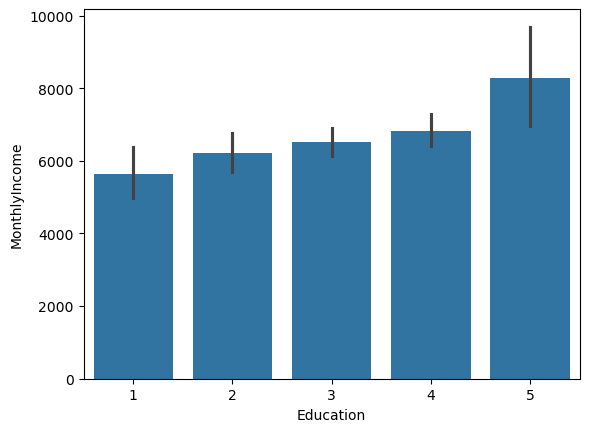

In [17]:
sns.barplot(x = df['Education'], 
            y = df['MonthlyIncome'], 
            data = df)

# Show the plot
plt.show()

### 3. Education field in the company

To see the different types of education the workers have, let's see the unique value first

In [18]:
df['EducationField'].unique()

array(['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

Now, let's plot the pie chart with percentages

([<matplotlib.patches.Wedge at 0x2109b123070>,
 [Text(0.2994329091618902, 1.0584611154458379, 'Life Sciences'),
  Text(-0.9951095091219136, -0.4687825347164123, 'Other'),
  Text(0.2194966396897843, -1.0778781123878958, 'Medical'),
  Text(0.806357022319634, -0.7481900510938471, 'Marketing'),
  Text(1.05386333339301, -0.315233365191208, 'Technical Degree'),
  Text(1.09816922292375, -0.06343782643697085, 'Human Resources')],
 [Text(0.16332704136103102, 0.5773424266068207, '41%'),
  Text(-0.5427870049755892, -0.2556995643907703, '32%'),
  Text(0.11972543983079142, -0.5879335158479431, '11%'),
  Text(0.4398311030834367, -0.4081036642330074, '9%'),
  Text(0.5748345454870963, -0.17194547192247708, '6%'),
  Text(0.5990013943220454, -0.03460245078380227, '2%')])

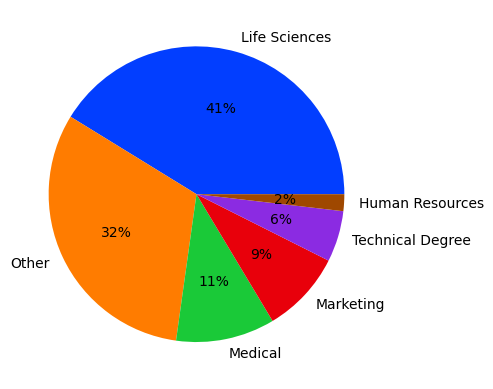

In [19]:
data = df['EducationField'].value_counts()
mylabels = ['Life Sciences', 'Other', 'Medical', 'Marketing',
       'Technical Degree', 'Human Resources']

palette_color = sns.color_palette('bright') 
  
plt.pie(data, labels=mylabels, colors=palette_color, autopct='%.0f%%')

There seems to be missing data for 'Other' degree holders. This column will most likely not be used for later machine learning features

### 4. Male Dominated and Female Dominated Department

Let's see different types of department first

In [20]:
df['Department'].unique()

array(['Sales', 'Research & Development', 'Human Resources'], dtype=object)

Then, the number of female and male workers

In [21]:
df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

As seen above, there are more male workers than female ones

Now let's see the pie chart for sales department

([<matplotlib.patches.Wedge at 0x2109b1919a0>,
 [Text(-0.2609318741906984, 1.0686040225599611, 'Male'),
  Text(0.26093197424062653, -1.068603998129751, 'Female')],
 [Text(-0.14232647683129004, 0.5828749213963423, '58%'),
  Text(0.1423265314039781, -0.5828749080707732, '42%')])

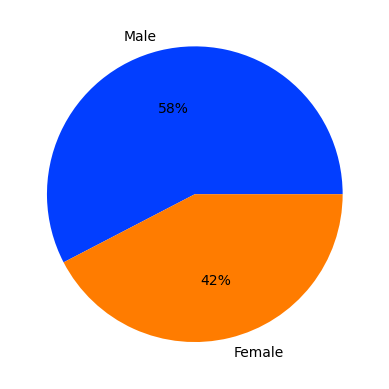

In [22]:
sales = df[df['Department'] == 'Sales']

data = sales['Gender'].value_counts()
mylabels = ['Male', 'Female']

palette_color = sns.color_palette('bright') 
  
plt.pie(data, labels=mylabels, colors=palette_color, autopct='%.0f%%')

From the graph the sales department seems to be male dominant

In [23]:
sales['Gender'].value_counts()

Gender
Male      257
Female    189
Name: count, dtype: int64

The same is also true for the stats

([<matplotlib.patches.Wedge at 0x2109b1e1cd0>,
 [Text(-0.3583326990633185, 1.039998883067668, 'Male'),
  Text(0.3583326990633186, -1.039998883067668, 'Female')],
 [Text(-0.1954541994890828, 0.5672721180369098, '61%'),
  Text(0.19545419948908285, -0.5672721180369098, '39%')])

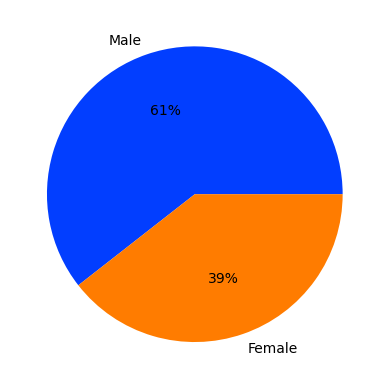

In [24]:
RnD = df[df['Department'] == 'Research & Development']

data = RnD['Gender'].value_counts()
mylabels = ['Male', 'Female']

palette_color = sns.color_palette('bright') 
  
plt.pie(data, labels=mylabels, colors=palette_color, autopct='%.0f%%')

In [25]:
RnD['Gender'].value_counts()

Gender
Male      582
Female    379
Name: count, dtype: int64

R&D department is also male dominant from both graph and stats

([<matplotlib.patches.Wedge at 0x2109b283bb0>,
 [Text(-0.5968009451817269, 0.924028479988684, 'Male'),
  Text(0.5968010316955141, -0.9240284241121429, 'Female')],
 [Text(-0.32552778828094187, 0.504015534539282, '68%'),
  Text(0.32552783547028036, -0.5040155040611688, '32%')])

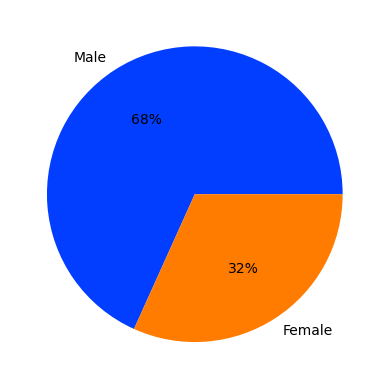

In [26]:
HumanRes = df[df['Department'] == 'Human Resources']

data = HumanRes['Gender'].value_counts()
mylabels = ['Male', 'Female']

palette_color = sns.color_palette('bright') 
  
plt.pie(data, labels=mylabels, colors=palette_color, autopct='%.0f%%')

In [27]:
HumanRes['Gender'].value_counts()

Gender
Male      43
Female    20
Name: count, dtype: int64

HR is also male dominated department

From the statistics and graph above, we can conclude that this company and its department are very male dominated

### 5. Correlation Test with Numerical Features

When creating a Machine Learning Model, we need to select features that have strong or significant correlation with our target. The less significant ones will only give "noise" to our model, which is unexplained variability within a data sample. This can cause our model to be more overfitting.When creating a Machine Learning Model, we need to select features that have strong or significant correlation with our target. The less significant ones will only give "noise" to our model, which is unexplained variability within a data sample. This can cause our model to be more overfitting.

Let's first set up our target for this correlation test

In [28]:
target = df['Attrition']

Let's take a look at it statistically instead

In [29]:
p_values = []
interpretasi = []
cols = []

for col in actual_num.columns:
  corr_coef, p_value = stats.kendalltau(actual_num[col], target)

  p_values.append(p_value)
  cols.append(col)

  if p_value < 0.05:
    interpretasi.append('Correlated')
  else :
    interpretasi.append('No Correlation')

pd.DataFrame({'Column Names':cols,
              'Result': interpretasi})

,Column Names,Result
0,Age,Correlated
1,DailyRate,Correlated
2,DistanceFromHome,Correlated
3,EmployeeCount,No Correlation
4,EmployeeNumber,No Correlation
5,HourlyRate,No Correlation
6,MonthlyIncome,Correlated
7,MonthlyRate,No Correlation
8,NumCompaniesWorked,No Correlation
9,PercentSalaryHike,No Correlation


For numerical columns the one I will choose are:
- Age because a person can be attrited when they reach a certain age
- DailyRate will be used because the higher the rating, the less likely the person will be attrited since the company will need them more
- DistanceFromHome will also be taken because the further the distance, the less effective and motivated they are working in the office
- MonthlyIncome will determine a person's willingness to keep working longer
- TotalWorkingYears will also determine a person's satisfaction with the job itself
- TrainingTimesLastYear will determine the performance of the workers
- YearsAtCompany is the same as TotalWorkingYears, but is instead how a person is satisfied with the company itself

Other columns are not selected because it is either not related statistic-wise or business-wise, or they may already be represented by other columns in which I have chosen above.

### 6. For Categorical Columns

Now we will see the correlation for categorical columns

In [30]:
p_values = []
interpretasi = []
cols = []

for col in actual_cat.columns:
  contingency_table = pd.crosstab(actual_cat[col], target) # contingency table is important for chi squared test
  chi2, p_value, _, _ = chi2_contingency(contingency_table)   

  p_values.append(p_value)
  cols.append(col)

  if p_value < 0.05:
    interpretasi.append('Correlated')
  else :
    interpretasi.append('No Correlation')

pd.DataFrame({'Column Names':cols,
              'Result': interpretasi})

,Column Names,Result
0,Attrition,Correlated
1,BusinessTravel,Correlated
2,Department,Correlated
3,EducationField,Correlated
4,Gender,No Correlation
5,JobRole,Correlated
6,MaritalStatus,Correlated
7,Over18,No Correlation
8,OverTime,Correlated


> Attrition will not be used because it is our target, not our features

For categorical columns the one I will choose are:
- BusinessTravel may determine a person's satisfaction or disatisfaction by the number of times they travel
- Department will be used instead of JobRole because it has less unique value, hence lesser cardinality
- Overtime is a good determinant because it usually demotivate employees to keep working for the company

Other columns are not selected because it is either not related statistic-wise or business-wise, or they may already be represented by other columns in which I have chosen above.

In [31]:
p_values = []
interpretasi = []
cols = []

for col in encoded_data.columns:
  contingency_table = pd.crosstab(encoded_data[col], target)
  chi2, p_value, _, _ = chi2_contingency(contingency_table)   

  p_values.append(p_value)
  cols.append(col)

  if p_value < 0.05:
    interpretasi.append('Correlated')
  else :
    interpretasi.append('No Correlation')

pd.DataFrame({'Column Names':cols,
              'Result': interpretasi})

,Column Names,Result
0,Education,No Correlation
1,EnvironmentSatisfaction,Correlated
2,JobInvolvement,Correlated
3,JobLevel,Correlated
4,JobSatisfaction,Correlated
5,RelationshipSatisfaction,No Correlation
6,StockOptionLevel,Correlated
7,WorkLifeBalance,Correlated


For encoded categorical columns the one I will choose are:
- EnvironmentSatisfaction represent how satisfied the workers are with the office and company environment
- JobSatisfaction represent how satisfied the workers are with the job itself
- StockOptionLevel is the level of stock a worker own, which may motivate the employee to work harder to raise the value of the company's stock
- WorkLifeBalance will be able to motivate the workers to keep working because they are given more freedom outside of working hours

Other columns are not selected because it is either not related statistic-wise or business-wise, or they may already be represented by other columns in which I have chosen above.

## Feature Engineering

### 1. Feature Selection and Splitting

I will select the choosen colums to be used from the analysis above for my X feature

In [32]:
X = df[['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'BusinessTravel', 'Department', 'OverTime', 'EnvironmentSatisfaction', 'JobSatisfaction', 'StockOptionLevel', 'WorkLifeBalance']]

Then, change the values of our target from yes/no to 1/0

In [33]:
y = df['Attrition'].str.replace('Yes', '1').replace('No', '0').astype('int')

In [34]:
y.head()

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int32

### 2. Cardinality Check

We must check cardinality to ensure the best performance when we encode the categorical values

In [35]:
cat_cols = list(X.select_dtypes(include='object').columns)

listItem = []
for col in cat_cols:
  listItem.append([col, X[col].nunique(), X[col].unique()])

pd.DataFrame(columns=['Column', 'Unique Values Total', 'Unique Values'], data=listItem)

,Column,Unique Values Total,Unique Values
0,BusinessTravel,3,"[Travel_Rarely, Travel_Frequently, Non-Travel]"
1,Department,3,"[Sales, Research & Development, Human Resources]"
2,OverTime,2,"[Yes, No]"


### 3. Splitting Train & Test

First we check the balance of the data

In [36]:
y.value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

> Because the data is imbalance, we will use SMOTE (Synthetic Minority Oversampling Technique) to balance the data

Then, we split between train and test

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.15, random_state = 2)

### 4. Handling Missing Values

Let's check for missing values before handling any outliers

In [38]:
print(X_train.isnull().sum())

Age                        0
DailyRate                  0
DistanceFromHome           0
MonthlyIncome              0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
BusinessTravel             0
Department                 0
OverTime                   0
EnvironmentSatisfaction    0
JobSatisfaction            0
StockOptionLevel           0
WorkLifeBalance            0
dtype: int64


In [39]:
print(X_test.isnull().sum())

Age                        0
DailyRate                  0
DistanceFromHome           0
MonthlyIncome              0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
BusinessTravel             0
Department                 0
OverTime                   0
EnvironmentSatisfaction    0
JobSatisfaction            0
StockOptionLevel           0
WorkLifeBalance            0
dtype: int64


In [40]:
print(y_train.isnull().sum())
print(y_test.isnull().sum())

0
0


Seems like there is no missing values

### 5. Handling Outlier

Before we decide to check for outlier, we need to check the skewness first for numerical features. Because skewed columns require different method to check for outliers (IQR Method) from normal ones (z-score method)

In [41]:
num_cols = list(X_train[['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany']].columns)

listItem= []

for col in num_cols:
  listItem.append([col, round(X_train[col].skew(),1), np.where(
    (round(X_train[col].skew(),1) <= 0.5) & (round(X_train[col].skew(),1) >= -0.5),
    'normal',
    'skewed')])



skewness = pd.DataFrame(columns=['Column', 'Skewness', 'Distribution'], data= listItem)
skewness

,Column,Skewness,Distribution
0,Age,0.5,normal
1,DailyRate,0.0,normal
2,DistanceFromHome,1.0,skewed
3,MonthlyIncome,1.4,skewed
4,TotalWorkingYears,1.2,skewed
5,TrainingTimesLastYear,0.6,skewed
6,YearsAtCompany,1.8,skewed


Now, we will check the percentage for outlier. As mentioned before, we will use IQR method to check if there are outliers for skewed columns, and z-score method for normal ones.

In [42]:
column = []
lower_bound = []
upper_bound = []
percent_total_outlier = []

for row in range (0, len(skewness)):
  col = skewness['Column'][row]
  #checking upper and lower boundary
  if skewness['Distribution'][row] == 'skewed':
    IQR = X_train[col].quantile(0.75) - X_train[col].quantile(0.25)
    lower_boundary = X_train[col].quantile(0.25) - (IQR * 3)
    upper_boundary = X_train[col].quantile(0.75) + (IQR * 3)
  else:
    lower_boundary = X_train[col].mean() - 3* X_train[col].std()
    upper_boundary = X_train[col].mean() + 3* X_train[col].std()
  #append to list
  column.append(col)
  lower_bound.append(lower_boundary)
  upper_bound.append(upper_boundary)
  totout = ((len(X_train[X_train[col] > upper_boundary]) / len(X_train) * 100) + (len(X_train[X_train[col] < lower_boundary]) / len(X_train) * 100))
  percent_total_outlier.append(totout)

outliers = pd.DataFrame({
    'column': column,
    #round the value
    'upper_boundary': [round(upper_bound,2) for upper_bound in upper_bound],
    'lower_boundary': [round(lower_bound,2) for lower_bound in lower_bound],
    'percentage_total_outlier': [round(percent_total_outlier,2) for percent_total_outlier in percent_total_outlier]
})
outliers

,column,upper_boundary,lower_boundary,percentage_total_outlier
0,Age,64.01,9.49,0.0
1,DailyRate,2022.91,-424.93,0.0
2,DistanceFromHome,50.00,-34.00,0.0
3,MonthlyIncome,24921.00,-13600.00,0.0
4,TotalWorkingYears,42.00,-21.00,0.0
5,TrainingTimesLastYear,6.00,-1.00,0.0
6,YearsAtCompany,27.00,-15.00,1.2


There won't be any need to handle the outliers because there is little to no amount of it. Besides, the 'YearsAtCompany' represents the length of time a person worked for the company (in years), and 'TotalWorkingYears' represents the length of time the person has been working. Because of this, there is no justification to cap or trim this error since every value of this feature will be needed.

What we will do instead for this particular is to scale it using MinMax method.

### 6. Pipeline

This part is the pipeline creation process. In the first part, we want to focus on pure feature engineering only. So we will not train the model yet, instead we want to focus on scaling and encoding our selected features

In [43]:
numerical_features_scaler = ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'TrainingTimesLastYear']  # kolum yang di-scale dengan standard
numerical_features_minmax = ['TotalWorkingYears','YearsAtCompany']  # kolum yang di-scale dengan minmax
categorical_features_onehot = ['Department', 'OverTime']  # kolum yang di-encode dengan onehot
categorical_features_ordinal = ['BusinessTravel'] # kolum yang di-encode dengan ordinal
biarkan = ['EnvironmentSatisfaction', 'JobSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'] # kolum yang di biarkan karena sudah di-encode




numerical_transformer_scaler = Pipeline(steps=[
    ('scaler', StandardScaler())
])
numerical_transformer_minmax = Pipeline(steps=[
    ('minmax', MinMaxScaler())
])
categorical_transformer_onehot = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
categorical_transformer_ordinal = Pipeline(steps=[
    ('ordinal', OrdinalEncoder())
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num_scaler', numerical_transformer_scaler, ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'TrainingTimesLastYear']),
        ('num_minmax', numerical_transformer_minmax, ['TotalWorkingYears','YearsAtCompany']),
        ('cat_onehot', categorical_transformer_onehot, ['Department', 'OverTime']),
        ('cat_ordinal', categorical_transformer_ordinal, ['BusinessTravel']),
        ('passthrough', 'passthrough', ['EnvironmentSatisfaction', 'JobSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'])
    ]
)

smote = SMOTE(sampling_strategy='minority', k_neighbors=5, random_state=2)

def array_to_dataframe(X, columns):
    """Convert numpy array back to DataFrame for ColumnTransformer compatibility."""
    return pd.DataFrame(X, columns=columns)


I will explain every function above:
1. Pipeline will act as algorithm chain that will be able to automate and streamline workflow for creating a model
2. Standard Scaler will standardized the features by making the mean of each feature into 0 and the standard deviation into 1
3. MinMax Scaler is useful for algorithm that is sensitive to outliers (Logistic Regression). The scaler transform the value of its feature by:
x' = (x - min(x)) / (max(x) - min(x))
4. OneHot encoder will create binary columns to the dataframe for each unique value
5. Ordinal encoder will change the value by assigning integer values for each values the feature represents
6. Preprocessor will allow the data to be scaled and encoded
7. SMOTE is a resampling method that can balance the data that can duplicate the minority label (in this case is 1) up to the same number as the majority label (0)

## Model Training

These columns will be put into the pipeline of the models:

In [44]:
# Check the transformed shape and column names after preprocessing
X_transformed = preprocessor.fit_transform(X_train)
print(f"Transformed shape: {X_transformed.shape}")
print(f"Transformed columns: {preprocessor.get_feature_names_out()}")


Transformed shape: (1249, 15)
Transformed columns: ['num_scaler__Age' 'num_scaler__DailyRate' 'num_scaler__DistanceFromHome'
 'num_scaler__MonthlyIncome' 'num_scaler__TrainingTimesLastYear'
 'num_minmax__TotalWorkingYears' 'num_minmax__YearsAtCompany'
 'cat_onehot__Department_Research & Development'
 'cat_onehot__Department_Sales' 'cat_onehot__OverTime_Yes'
 'cat_ordinal__BusinessTravel' 'passthrough__EnvironmentSatisfaction'
 'passthrough__JobSatisfaction' 'passthrough__StockOptionLevel'
 'passthrough__WorkLifeBalance']


These are the model we will train to be used later:

In [45]:
# Create pipeline for KNN
pipe_knn = ImbPipeline([
    ('transformer', preprocessor),
    ('smote', smote),
    ('to_dataframe', FunctionTransformer(array_to_dataframe, kw_args={'columns': [
        'num_scaler__Age', 'num_scaler__DailyRate', 'num_scaler__DistanceFromHome',
        'num_scaler__MonthlyIncome', 'num_scaler__TrainingTimesLastYear',
        'num_minmax__TotalWorkingYears', 'num_minmax__YearsAtCompany',
        'cat_onehot__Department_Research & Development', 'cat_onehot__Department_Sales', 
        'cat_onehot__OverTime_Yes', 'cat_ordinal__BusinessTravel',
        'passthrough__EnvironmentSatisfaction', 'passthrough__JobSatisfaction', 
        'passthrough__StockOptionLevel', 'passthrough__WorkLifeBalance'
    ]})),
    ('classifier', KNeighborsClassifier(n_neighbors=3))
])

# Create pipeline for Decision Tree
pipe_dt = ImbPipeline([
    ('transformer', preprocessor),
    ('smote', smote),
    ('to_dataframe', FunctionTransformer(array_to_dataframe, kw_args={'columns': [
        'num_scaler__Age', 'num_scaler__DailyRate', 'num_scaler__DistanceFromHome',
        'num_scaler__MonthlyIncome', 'num_scaler__TrainingTimesLastYear',
        'num_minmax__TotalWorkingYears', 'num_minmax__YearsAtCompany',
        'cat_onehot__Department_Research & Development', 'cat_onehot__Department_Sales', 
        'cat_onehot__OverTime_Yes', 'cat_ordinal__BusinessTravel',
        'passthrough__EnvironmentSatisfaction', 'passthrough__JobSatisfaction', 
        'passthrough__StockOptionLevel', 'passthrough__WorkLifeBalance'
    ]})),
    ('classifier', DecisionTreeClassifier(max_depth=8, min_samples_split=4, min_samples_leaf=4, random_state=2))
])

# Create pipeline for Random Forest
pipe_rf = ImbPipeline([
    ('transformer', preprocessor),
    ('smote', smote),
    ('to_dataframe', FunctionTransformer(array_to_dataframe, kw_args={'columns': [
        'num_scaler__Age', 'num_scaler__DailyRate', 'num_scaler__DistanceFromHome',
        'num_scaler__MonthlyIncome', 'num_scaler__TrainingTimesLastYear',
        'num_minmax__TotalWorkingYears', 'num_minmax__YearsAtCompany',
        'cat_onehot__Department_Research & Development', 'cat_onehot__Department_Sales', 
        'cat_onehot__OverTime_Yes', 'cat_ordinal__BusinessTravel',
        'passthrough__EnvironmentSatisfaction', 'passthrough__JobSatisfaction', 
        'passthrough__StockOptionLevel', 'passthrough__WorkLifeBalance'
    ]})),
    ('classifier', RandomForestClassifier(random_state=2))
])

# Create pipeline for XGBoost
pipe_xgb = ImbPipeline([
    ('transformer', preprocessor),
    ('smote', smote),
    ('to_dataframe', FunctionTransformer(array_to_dataframe, kw_args={'columns': [
        'num_scaler__Age', 'num_scaler__DailyRate', 'num_scaler__DistanceFromHome',
        'num_scaler__MonthlyIncome', 'num_scaler__TrainingTimesLastYear',
        'num_minmax__TotalWorkingYears', 'num_minmax__YearsAtCompany',
        'cat_onehot__Department_Research & Development', 'cat_onehot__Department_Sales', 
        'cat_onehot__OverTime_Yes', 'cat_ordinal__BusinessTravel',
        'passthrough__EnvironmentSatisfaction', 'passthrough__JobSatisfaction', 
        'passthrough__StockOptionLevel', 'passthrough__WorkLifeBalance'
    ]})),
    ('classifier', XGBClassifier())
])

# Create pipeline for SVC
pipe_svc = ImbPipeline([
    ('transformer', preprocessor),
    ('smote', smote),
    ('to_dataframe', FunctionTransformer(array_to_dataframe, kw_args={'columns': [
        'num_scaler__Age', 'num_scaler__DailyRate', 'num_scaler__DistanceFromHome',
        'num_scaler__MonthlyIncome', 'num_scaler__TrainingTimesLastYear',
        'num_minmax__TotalWorkingYears', 'num_minmax__YearsAtCompany',
        'cat_onehot__Department_Research & Development', 'cat_onehot__Department_Sales', 
        'cat_onehot__OverTime_Yes', 'cat_ordinal__BusinessTravel',
        'passthrough__EnvironmentSatisfaction', 'passthrough__JobSatisfaction', 
        'passthrough__StockOptionLevel', 'passthrough__WorkLifeBalance'
    ]})),
    ('classifier', SVC(probability=True, kernel='rbf', random_state=2))
])


- KNearest Neighbor does not assumes linearity between features and label, which may make it good for this model because it assumes nothing. The parameter for the number of neighbors is set to be 3 as the base
- Decision Tree as a base without parameter won't likely produce a good model. Because of this, I will add random parameter for this model.
- Random Forrest will improve the accuracy and robustness of the classifier model by combining the prediction of multiple trees. This does not need parameter unlike decision tree.
- XGBoost will build a series of decision trees, with each trees improve the errors of the previous one. 
- Support Vector Classifier (particularly RBF) will be able to map data to a higher dimension where it becomes linearly seperable. This model will also require parameters before we decide if it will be good fit or not.

All random state will be set to 2 for the result to be consistent.

## Model Evaluation

In this part, we will first evaluate the metrics for the base model that is already trained above. The metrics that we will look at are recall and ROC AUC. For the recall, we will do cross validation only for the training data of X and y. The recall and ROC AUC metric will of course be used for the test, but the difference is that the test is the actual result of the model.

After we gather the metrics of the model, we will decide which one to use based on the score of both ROC AUC and recall. We will also take into account the Area Under the Curve by creating a graph.

### Base Model Evaluation

#### 1. KNeares Neighbor

In [46]:
pipe_knn.fit(X_train, y_train)
y_pred_train = pipe_knn.predict(X_train)
y_pred = pipe_knn.predict(X_test)

recall_train_cross_val = cross_val_score(pipe_knn,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: Logistic Regression")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: Logistic Regression
Recall - All - Cross Validation  :  [0.48780488 0.46341463 0.51219512 0.3902439  0.53658537]
Recall - Mean - Cross Validation :  0.47804878048780486
Recall - Std - Cross Validation  :  0.05022258605359513
Recall - Range of Test-Set       :  0.4278261944342097 - 0.5282713665414
Recall test score: 0.625
Roc auc test score: 0.7013888888888888


The recall test score is high compared to the average recall train score. The result of the test is also above the expected range. This can indicate underfitting.

As for the ROC AUC test, it's better than the recall

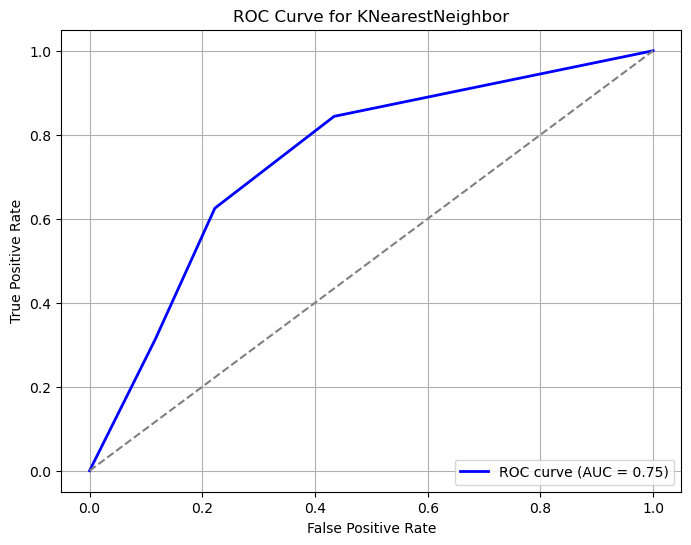

In [47]:
# Calculate ROC curve
y_probs = pipe_knn.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for KNearestNeighbor')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

From the line, we can see that the model (Logistic Regression) assumes linearity by how straight the shape of the line is. The area under the curve is still above 0.5. This shows a strong ability to distinguish between negative and positive classes or categorical result (y).

We will see the confusion matrix to see the false negative of the model prediction

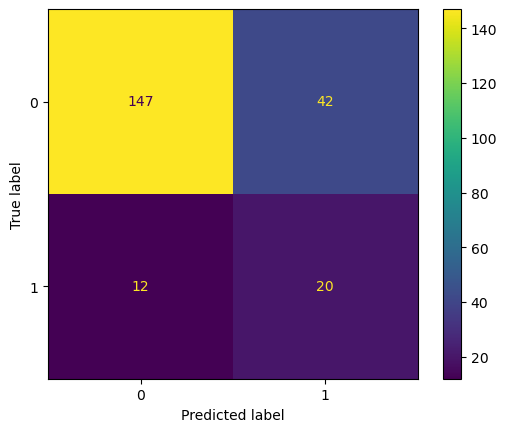

In [48]:
cm_test = confusion_matrix(y_test, pipe_knn.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

From the matrix above, there is a high tendency to predict false positive. Even if our main focus is on False Negative, we still want to have a balanced data that can predict the label properly

In [49]:
Eval_knn = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [12, recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.75]
}
Eval_knn = pd.DataFrame(Eval_knn)

The metric scores will be put into dataframe for further evaluation.

> Note: The reason recall train score cross validation mean is used is because if the model is already fitted, the accuracy will always be 100% for the training data

#### 2. Decision Tree

In [50]:
pipe_dt.fit(X_train, y_train)
y_pred_train = pipe_dt.predict(X_train)
y_pred = pipe_dt.predict(X_test)

recall_train_cross_val = cross_val_score(pipe_dt,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: Decision Tree")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: Decision Tree
Recall - All - Cross Validation  :  [0.48780488 0.34146341 0.43902439 0.34146341 0.41463415]
Recall - Mean - Cross Validation :  0.40487804878048783
Recall - Std - Cross Validation  :  0.05688733555946633
Recall - Range of Test-Set       :  0.3479907132210215 - 0.4617653843399542
Recall test score: 0.28125
Roc auc test score: 0.5824239417989419


Both the recall and ROC AUC are lower than the previous model. This could be due to not selecting the right parameter or it is simply the model's fault. Unfortunately, we don't have the time nor resources to test different parameters for this particular model. So, I will just conclude that this particular model is not a good fit. 

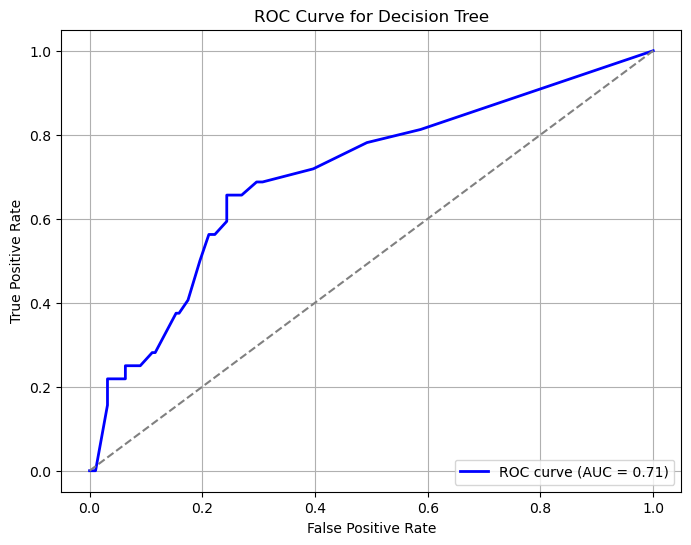

In [51]:
# Calculate ROC curve
y_probs = pipe_dt.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The curve for the graph above shows the area under the curve to be 71%

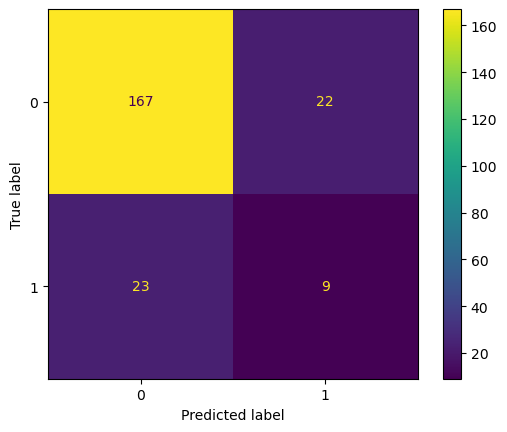

In [52]:
cm_test = confusion_matrix(y_test, pipe_dt.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

The number of False Negative is higher than false positive, which makes it not a good fit for our model. The number of false positive may also raise some warnings

In [53]:
Eval_dt = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [23,recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.71]
}
Eval_dt = pd.DataFrame(Eval_dt)

Then, the model will be saved

#### 3. Random Forrest

In [54]:
pipe_rf.fit(X_train, y_train)
y_pred_train = pipe_rf.predict(X_train)
y_pred = pipe_rf.predict(X_test)

recall_train_cross_val = cross_val_score(pipe_rf,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: Random Forrest")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: Random Forrest
Recall - All - Cross Validation  :  [0.31707317 0.31707317 0.36585366 0.31707317 0.3902439 ]
Recall - Mean - Cross Validation :  0.34146341463414637
Recall - Std - Cross Validation  :  0.030851489367496387
Recall - Range of Test-Set       :  0.31061192526665 - 0.37231490400164274
Recall test score: 0.375
Roc auc test score: 0.6689814814814815


The ROC AUC score for this model may be the highest, however the recall score is still low. The actual test score is above the expected range.

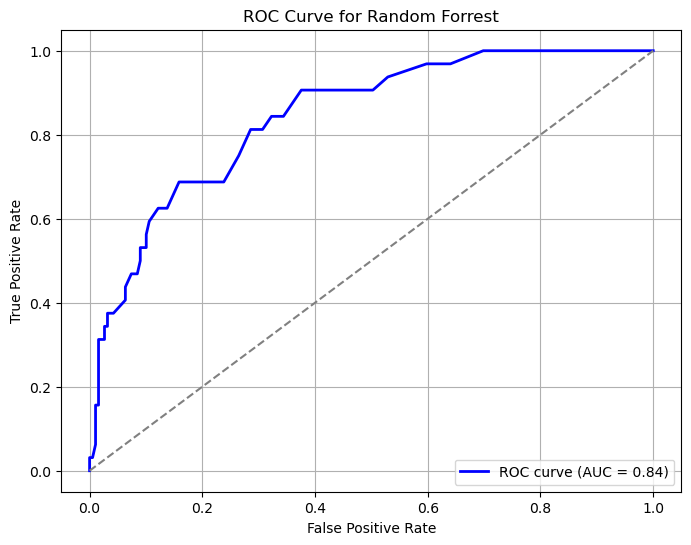

In [55]:
# Calculate ROC curve
y_probs = pipe_rf.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Random Forrest')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The graph above shows better ability to distinguish classes because it is 84%.

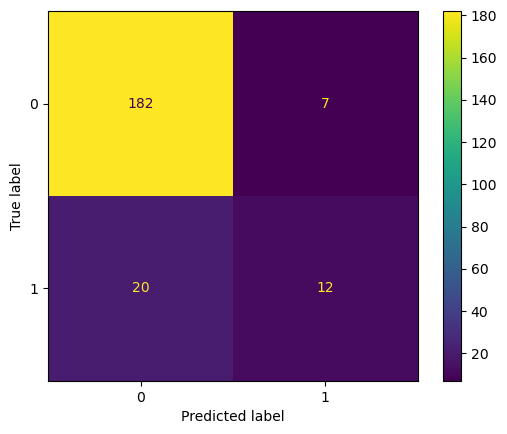

In [56]:
cm_test = confusion_matrix(y_test, pipe_rf.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

The number of false negatives is almost as high as the previous model, but has lower tendency to identify False Positives.

In [57]:
Eval_rf = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [20, recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.84]
}
Eval_rf = pd.DataFrame(Eval_rf)

#### 4. XGBoost

In [58]:
pipe_xgb.fit(X_train, y_train)
y_pred_train = pipe_xgb.predict(X_train)
y_pred = pipe_xgb.predict(X_test)

recall_train_cross_val = cross_val_score(pipe_xgb,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: XGBoost")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: XGBoost
Recall - All - Cross Validation  :  [0.34146341 0.34146341 0.41463415 0.31707317 0.43902439]
Recall - Mean - Cross Validation :  0.37073170731707317
Recall - Std - Cross Validation  :  0.04729443763333003
Recall - Range of Test-Set       :  0.32343726968374314 - 0.4180261449504032
Recall test score: 0.4375
Roc auc test score: 0.6949404761904762


The recall test score might be the highest so far

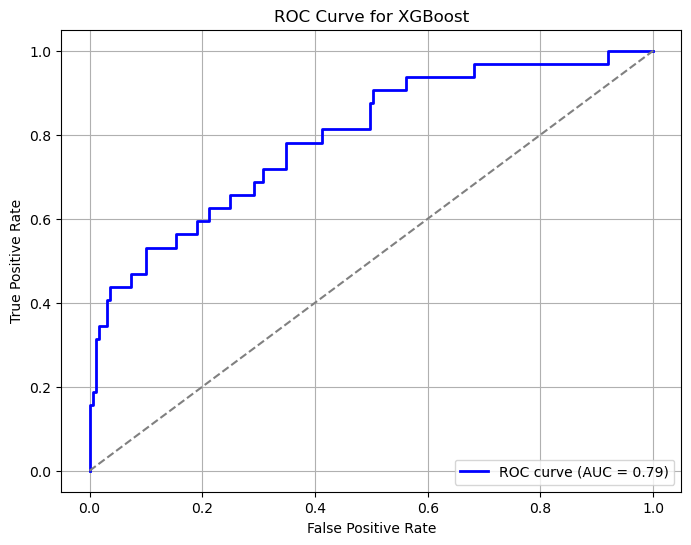

In [59]:
# Calculate ROC curve
y_probs = pipe_xgb.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

From the Area Under the Curve, we can see that it is lower than before

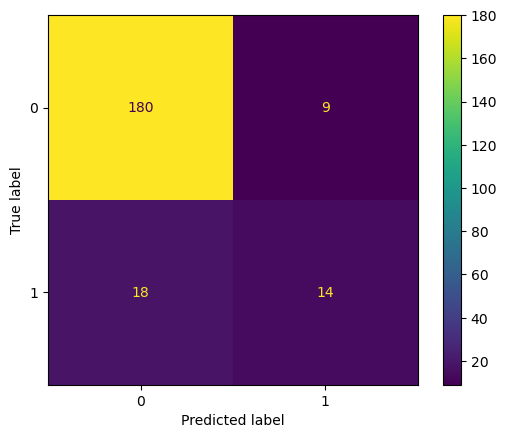

In [60]:
cm_test = confusion_matrix(y_test, pipe_xgb.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

In [61]:
Eval_xgb = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [18, recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.79]
}
Eval_xgb = pd.DataFrame(Eval_xgb)

#### 5. SVC

In [62]:
pipe_svc.fit(X_train, y_train)
y_pred_train = pipe_svc.predict(X_train)
y_pred = pipe_svc.predict(X_test)

recall_train_cross_val = cross_val_score(pipe_svc,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: Support Vector Classifier")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: Support Vector Classifier
Recall - All - Cross Validation  :  [0.56097561 0.6097561  0.58536585 0.53658537 0.65853659]
Recall - Mean - Cross Validation :  0.5902439024390245
Recall - Std - Cross Validation  :  0.04196256227825671
Recall - Range of Test-Set       :  0.5482813401607678 - 0.6322064647172811
Recall test score: 0.71875
Roc auc test score: 0.761491402116402


The score alone should tell us that it is the best model and should be the only used out of all the models shown above. The ROC AUC score is by far the highest, not to mention ho high the recall score for this model is. The recall score is also within the expected range.

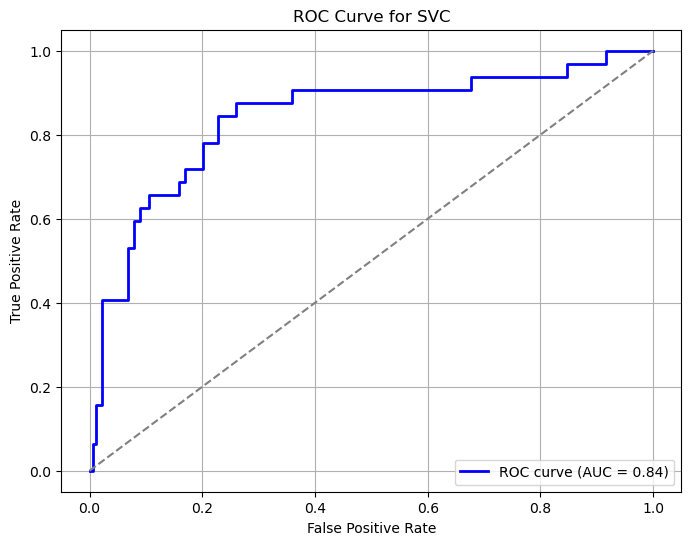

In [63]:
# Calculate ROC curve
y_probs = pipe_svc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVC')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

This model has the highest Area Under Curve

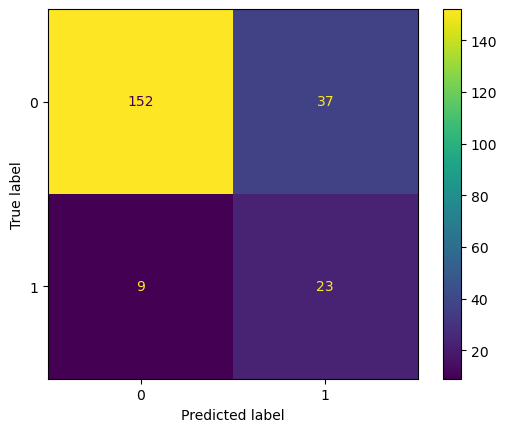

In [64]:
cm_test = confusion_matrix(y_test, pipe_svc.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

This model has the lowest number of false negatives so we will use it

In [65]:
Eval_svc = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [9, recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.84]
}
Eval_svc = pd.DataFrame(Eval_svc)

### Metric Evaluation

Here is the evaluation of the metric we use

In [66]:
Evaluation = pd.concat([Eval_knn[['Metric', 'Score']], Eval_dt['Score'], Eval_rf['Score'], Eval_xgb['Score'], Eval_svc['Score']], axis=1)
Evaluation.columns = ['Metric', 'KNearest Neighbor', 'Decision Tree Classifier', 'Random Forrest Classifier', 'XGBoost', 'SVC']
Evaluation

,Metric,KNearest Neighbor,Decision Tree Classifier,Random Forrest Classifier,XGBoost,SVC
0,False Negatives,12.000000,23.000000,20.000000,18.000000,9.000000
1,Recall train,0.478049,0.404878,0.341463,0.370732,0.590244
2,Recall Score,0.625000,0.281250,0.375000,0.437500,0.718750
3,Roc Auc Score,0.701389,0.582424,0.668981,0.694940,0.761491
4,Area Under Curve,0.750000,0.710000,0.840000,0.790000,0.840000


From the result above, I have decided that SVC is the best model because it has the highest recall score (which is the metric we want to focus on) and ROC AUC score (our secondary metric). Not to mention that this model has AUC of 82%, which is the highest. A high AUC score means that the model wll be able to distinguish negative and positive label properly.

### Hyper Parameter Tuning

First, we want to see the parameters our classifier model use:

In [67]:
pipe_svc.get_params().keys()

dict_keys(['memory', 'steps', 'verbose', 'transformer', 'smote', 'to_dataframe', 'classifier', 'transformer__force_int_remainder_cols', 'transformer__n_jobs', 'transformer__remainder', 'transformer__sparse_threshold', 'transformer__transformer_weights', 'transformer__transformers', 'transformer__verbose', 'transformer__verbose_feature_names_out', 'transformer__num_scaler', 'transformer__num_minmax', 'transformer__cat_onehot', 'transformer__cat_ordinal', 'transformer__passthrough', 'transformer__num_scaler__memory', 'transformer__num_scaler__steps', 'transformer__num_scaler__verbose', 'transformer__num_scaler__scaler', 'transformer__num_scaler__scaler__copy', 'transformer__num_scaler__scaler__with_mean', 'transformer__num_scaler__scaler__with_std', 'transformer__num_minmax__memory', 'transformer__num_minmax__steps', 'transformer__num_minmax__verbose', 'transformer__num_minmax__minmax', 'transformer__num_minmax__minmax__clip', 'transformer__num_minmax__minmax__copy', 'transformer__num_mi

Then we will test it with grid search.

In [68]:
param_grid = {
    'classifier__kernel': ('linear', 'rbf') , 
    'classifier__C':[10, 100, 200],
    'classifier__gamma': [1, 0.1,0.01], 
}

grid_search = GridSearchCV(pipe_svc, param_grid, cv=5, scoring='recall')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Recall score: {grid_search.best_score_}")

Best Parameters: {'classifier__C': 10, 'classifier__gamma': 1, 'classifier__kernel': 'linear'}
Best Recall score: 0.7170731707317073


The reason I use grid search is because I want to get the best result as accurate as possible. In order to not take too much time, the parameters chosen will be minimized.

In [69]:
best_model = grid_search.best_estimator_
best_model

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num_scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'MonthlyIncome',
                                                   'TrainingTimesLastYear']),
                                                 ('num_minmax',
                                                  Pipeline(steps=[('minmax',
                                                                   MinMaxScaler())]),
                                                  ['TotalWorkingYears',
                                                   'YearsAtCompany']),
                                                 ('cat_onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEnc...
                                                          'cat_onehot__Department_Research '
                                                          '& Development',
                                                          'cat_onehot__Department_Sales',
                                                          'cat_onehot__OverTime_Yes',
                                                          'cat_ordinal__BusinessTravel',
                                                          'passthrough__EnvironmentSatisfaction',
                                                          'passthrough__JobSatisfaction',
                                                          'passthrough__StockOptionLevel',
                                                          'passthrough__WorkLifeBalance']})),
                ('classifier',
                 SVC(C=10, gamma=1, kernel='linear', probability=True,
                     random_state=2))])

### Hyper Parameter Evaluation

In [70]:
y_pred_train = best_model.predict(X_train)
y_pred = best_model.predict(X_test)

recall_train_cross_val = cross_val_score(best_model,
                                     X_train,
                                     y_train,
                                     cv=5,
                                     scoring='recall')
print(f"Selected Model: SVC with tuning")
print('Recall - All - Cross Validation  : ', recall_train_cross_val)
print('Recall - Mean - Cross Validation : ', recall_train_cross_val.mean())
print('Recall - Std - Cross Validation  : ', recall_train_cross_val.std())
print('Recall - Range of Test-Set       : ', (recall_train_cross_val.mean()-recall_train_cross_val.std()) , '-', (recall_train_cross_val.mean()+recall_train_cross_val.std()))

print(f"Recall test score: {recall_score(y_test, y_pred)}")
print(f"Roc auc test score: {roc_auc_score(y_test, y_pred)}")

Selected Model: SVC with tuning
Recall - All - Cross Validation  :  [0.63414634 0.80487805 0.68292683 0.70731707 0.75609756]
Recall - Mean - Cross Validation :  0.7170731707317073
Recall - Std - Cross Validation  :  0.05894168767607109
Recall - Range of Test-Set       :  0.6581314830556362 - 0.7760148584077784
Recall test score: 0.71875
Roc auc test score: 0.7456183862433863


The train score seems more appropriate for the model and the test score

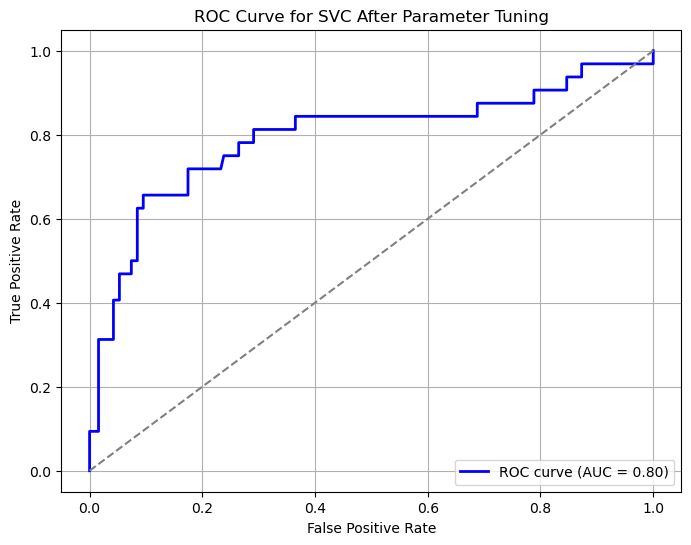

In [71]:
# Calculate ROC curve
y_probs = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs) 
roc_auc = auc(fpr, tpr)
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVC After Parameter Tuning')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

The AUC is lower than the base model

To check if the model has tendency towards False Positive or Negative, I will display the confusion matrix:

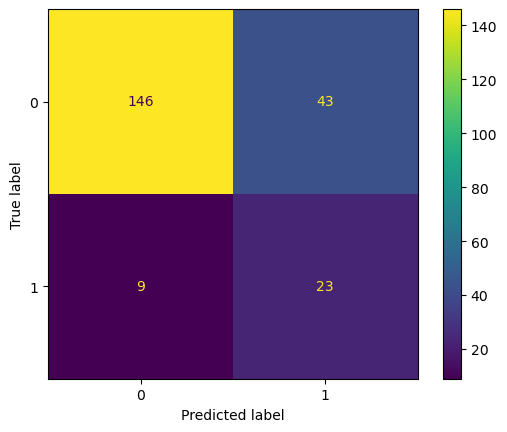

In [72]:
cm_test = confusion_matrix(y_test, best_model.predict(X_test))
ConfusionMatrixDisplay(cm_test).plot()

From the confusion matrix above, we can say that the model has the same False Negative than the base model

In [73]:
Eval_best = {
    'Metric': ['False Negatives', 'Recall train', 'Recall Score', 'Roc Auc Score', 'Area Under Curve'],
    'Score': [9,recall_train_cross_val.mean(), recall_score(y_test, y_pred), roc_auc_score(y_test, y_pred), 0.8]
}
Eval_best = pd.DataFrame(Eval_best)

Now let's compare the before and after parameter tuning of the model

In [74]:
BeforeVsAfter = pd.concat([Eval_svc[['Metric', 'Score']], Eval_best['Score']], axis=1)
BeforeVsAfter.columns = ['Metric', 'SVC Baseline', 'SVC Tuned']

In [75]:
BeforeVsAfter

,Metric,SVC Baseline,SVC Tuned
0,False Negatives,9.000000,9.000000
1,Recall train,0.590244,0.717073
2,Recall Score,0.718750,0.718750
3,Roc Auc Score,0.761491,0.745618
4,Area Under Curve,0.840000,0.800000


The tuned model seems to have lower score than the baseline model if we see their ROC AUC score and area under curve. However, if we consider the training recall score along with the test score, we can see that the tuned model seems to have a better fit than the base model. Because of this, the tuned model will be use to predict attrition.

## Model Saving

In [76]:
best_model

Pipeline(steps=[('transformer',
                 ColumnTransformer(transformers=[('num_scaler',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'MonthlyIncome',
                                                   'TrainingTimesLastYear']),
                                                 ('num_minmax',
                                                  Pipeline(steps=[('minmax',
                                                                   MinMaxScaler())]),
                                                  ['TotalWorkingYears',
                                                   'YearsAtCompany']),
                                                 ('cat_onehot',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEnc...
                                                          'cat_onehot__Department_Research '
                                                          '& Development',
                                                          'cat_onehot__Department_Sales',
                                                          'cat_onehot__OverTime_Yes',
                                                          'cat_ordinal__BusinessTravel',
                                                          'passthrough__EnvironmentSatisfaction',
                                                          'passthrough__JobSatisfaction',
                                                          'passthrough__StockOptionLevel',
                                                          'passthrough__WorkLifeBalance']})),
                ('classifier',
                 SVC(C=10, gamma=1, kernel='linear', probability=True,
                     random_state=2))])

In [77]:
joblib.dump(best_model, open('model_best.pkl', 'wb'))

> pickle was not able to load or store the mode, so I use joblib instead.

## Conclusion

### Metric Result

The goal of this model is to minimize the number of false negative because if an employee is attrited from the company without any prediction it can happen, the company will loose resources trying to find replacement. Because of this, our primary parameter focus is on False Negative. The use of ROC AUC is to test the accuracy of the model in a neutral kind of way (no focus on false positive or negative).

Here are the metric results of our models:

In [78]:
Overall = pd.concat([Eval_knn[['Metric', 'Score']], Eval_dt['Score'], Eval_rf['Score'], Eval_svc['Score'], Eval_xgb['Score'], Eval_best['Score']], axis=1)
Overall.columns = ['Metric', 'Logistic Regression', 'Decision Tree Classifier', 'Random Forrest Classifier', 'SVC', 'XGBoost', 'SVC with tuning']
Overall

,Metric,Logistic Regression,Decision Tree Classifier,Random Forrest Classifier,SVC,XGBoost,SVC with tuning
0,False Negatives,12.000000,23.000000,20.000000,9.000000,18.000000,9.000000
1,Recall train,0.478049,0.404878,0.341463,0.590244,0.370732,0.717073
2,Recall Score,0.625000,0.281250,0.375000,0.718750,0.437500,0.718750
3,Roc Auc Score,0.701389,0.582424,0.668981,0.761491,0.694940,0.745618
4,Area Under Curve,0.750000,0.710000,0.840000,0.840000,0.790000,0.800000


What I take a look at first is false negatives, recall, then ROC AUC score. These two score will be seen before the AUC. Overall, the model I choose (baseline SVC) has the best score considerably.

### Pros and Cons of The Model

Pros:

Our model was able to predict the attrition for unhappy employee and the happy ones. If we take a look at the model statistically, our model has a false negative of only 4% from the confusion matrix (9/221). This model was also able to cover the AUC pretty well (80%), not to mention the recall and ROC AUC test is also the highest.

Cons:

Despite some success in identifying workers within the company, this model is not suitable for potential candidate that are in the process of recruitment. This model still has a tendency to predict false negatives if you take a look at the inference data. Workers that are supposed to be in retirement age were not predicted to be attrited even though it is the main factor.

### Suggestion
The data that we used happened to be balanced using SMOTE. Because of this, the data may have tendency to predict employees to be attrited because it happens to be the minority data. The base model also happens to have higher score than the tuned model. This may be caused by the data balancing. Hence, we may need to choose better model for the prediction.

The need for more data is also my suggestion. Age should have positive correlation towards attrition because the data we use for the inference part are people who are supposed to retire. We need to convince the model that the higher the age, the higher the chances for attrition despite compensation and performance of the worker.

### EDA Insights:

- People who travel a lot has higher chance of being attrited
- Education level affect salary 
- Most people that worked in this company holds degree in life science
- All department in this company are male dominated